In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
file_path = '/content/Darknet.csv'
df = pd.read_csv(file_path)


# Basic Dataset Information
print("Dataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())


# Select only numeric columns
numeric_df = df.select_dtypes(include='number')
print("Numeric Columns Info:")
print(numeric_df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158616 entries, 0 to 158615
Data columns (total 85 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow ID                     158616 non-null  object 
 1   Src IP                      158616 non-null  object 
 2   Src Port                    158616 non-null  int64  
 3   Dst IP                      158616 non-null  object 
 4   Dst Port                    158616 non-null  int64  
 5   Protocol                    158616 non-null  int64  
 6   Timestamp                   158616 non-null  object 
 7   Flow Duration               158616 non-null  int64  
 8   Total Fwd Packet            158616 non-null  int64  
 9   Total Bwd packets           158616 non-null  int64  
 10  Total Length of Fwd Packet  158616 non-null  int64  
 11  Total Length of Bwd Packet  158616 non-null  int64  
 12  Fwd Packet Length Max       158616 non-null  int64  
 13  

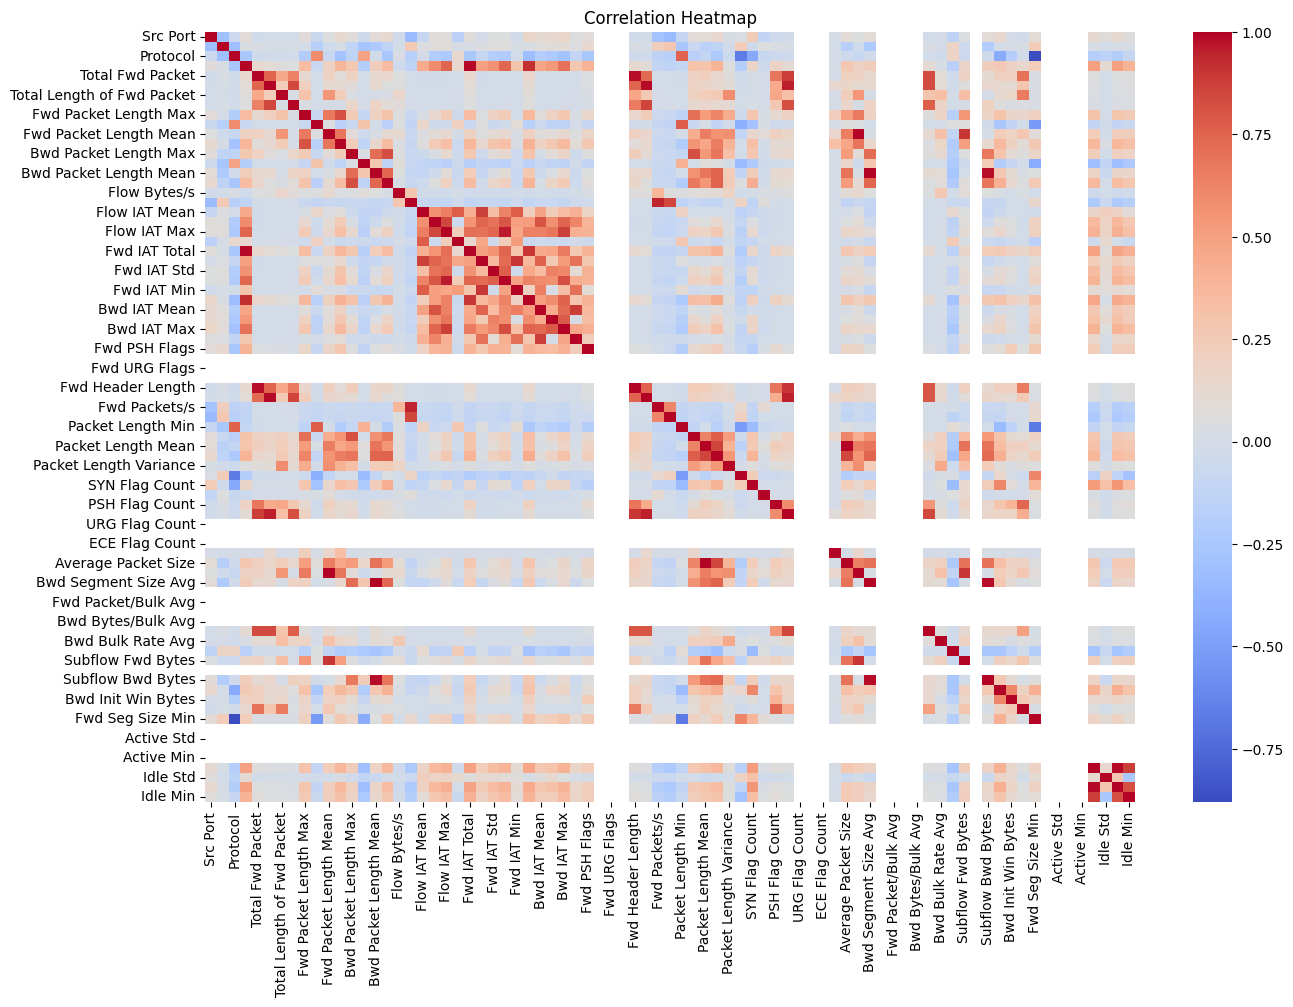

In [5]:
# Correlation Heatmap
plt.figure(figsize=(15, 10))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [6]:
# Identify highly correlated features
correlation_threshold = 0.85
high_corr_pairs = []

# Loop through the matrix and find pairs with high correlation
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((colname_i, colname_j, corr_value))

# Display highly correlated pairs
print("Highly Correlated Feature Pairs (|correlation| > 0.85):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]} -> Correlation: {pair[2]:.2f}")

Highly Correlated Feature Pairs (|correlation| > 0.85):
Total Length of Bwd Packet and Total Bwd packets -> Correlation: 0.85
Flow IAT Max and Flow IAT Std -> Correlation: 0.85
Fwd IAT Total and Flow Duration -> Correlation: 0.99
Fwd IAT Mean and Flow IAT Mean -> Correlation: 0.87
Fwd IAT Max and Flow IAT Max -> Correlation: 0.96
Fwd IAT Min and Fwd IAT Mean -> Correlation: 0.90
Bwd IAT Total and Flow Duration -> Correlation: 0.92
Bwd IAT Total and Fwd IAT Total -> Correlation: 0.90
Bwd IAT Max and Flow IAT Max -> Correlation: 0.87
Bwd IAT Min and Bwd IAT Mean -> Correlation: 0.88
Fwd Header Length and Total Fwd Packet -> Correlation: 0.98
Bwd Header Length and Total Bwd packets -> Correlation: 0.99
Bwd Header Length and Total Length of Bwd Packet -> Correlation: 0.86
Fwd Packets/s and Flow Packets/s -> Correlation: 0.94
Packet Length Std and Packet Length Mean -> Correlation: 0.86
ACK Flag Count and Total Fwd Packet -> Correlation: 0.88
ACK Flag Count and Total Bwd packets -> Correlat

In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())
# Remove duplicate rows
df = df.drop_duplicates(keep='first')
print(f"New dataset shape after removing duplicates: {df.shape}")


# Recheck for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())
# Handle Infinite Values
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)


# Check for NaN values after replacing infinities
nan_counts = numeric_df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
print("Columns with NaN Values After Replacing Infinities:")
print(nan_counts)


# Drop rows with NaN values
numeric_df = numeric_df.dropna()
# Standardization
scaler = StandardScaler()
standardized_data = scaler.fit_transform(numeric_df)
standardized_df = pd.DataFrame(standardized_data, columns=numeric_df.columns)


print("Standardized Data Preview:")
print(standardized_df.head(2))
# Check Variance
variance_threshold = 0.01  # threshold
low_variance_columns = standardized_df.var()[standardized_df.var() < variance_threshold].index.tolist()


print(f"Number of Low Variance Columns (Variance < {variance_threshold}): {len(low_variance_columns)}")
print("Low Variance Columns:")
print(low_variance_columns)
# Extract columns to drop from already identified high_corr_pairs
columns_to_drop = set([pair[0] for pair in high_corr_pairs])  # Drop the first column in each pair


# Drop Low Variance and Highly Correlated Columns
print(f"Number of Low Variance Columns: {len(low_variance_columns)}")
print(f"Number of Highly Correlated Columns: {len(columns_to_drop)}")


print("Dropping Low Variance and Highly Correlated Columns")
reduced_df = standardized_df.drop(columns=low_variance_columns + list(columns_to_drop))


# Display final column count
print(f"\nNumber of Remaining Columns after Feature Reduction: {len(reduced_df.columns)}")
print("Remaining Columns:", reduced_df.columns.tolist())


# Check unique classes in the label column
print("Unique Classes in Label Column:")
print(df['Label'].unique())


# Check class distribution
print("\nClass Distribution:")
print(df['Label'].value_counts())


# Initialize OneHotEncoder for Label and Label.1
encoder = OneHotEncoder(sparse_output=False)


# Perform One-Hot Encoding on Label and Label.1
encoded_labels = encoder.fit_transform(df[['Label', 'Label.1']])


# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_labels, columns=encoder.get_feature_names_out(['Label', 'Label.1']))


# Drop the original label columns and concatenate the encoded labels
df_encoded = pd.concat([df.drop(columns=['Label', 'Label.1']), encoded_df], axis=1)


print("\nOne-Hot Encoded Labels Preview:")
print(encoded_df.head())
print("\nDataset Shape after Encoding:", df_encoded.shape)

Number of duplicate rows: 0
New dataset shape after removing duplicates: (119612, 85)
Number of duplicate rows: 0
Columns with NaN Values After Replacing Infinities:
Series([], dtype: int64)
Standardized Data Preview:
   Src Port  Dst Port  Protocol  Flow Duration  Total Fwd Packet  \
0  0.976241 -0.768559  -0.78203      -0.543455         -0.061661   
1  0.976293 -0.768559  -0.78203      -0.543450         -0.061661   

   Total Bwd packets  Total Length of Fwd Packet  Total Length of Bwd Packet  \
0          -0.043666                   -0.032777                   -0.027695   
1          -0.043666                   -0.032777                   -0.027695   

   Fwd Packet Length Max  Fwd Packet Length Min  ...  Fwd Act Data Pkts  \
0              -0.333167              -0.499826  ...          -0.058603   
1              -0.333167              -0.499826  ...          -0.058603   

   Fwd Seg Size Min  Active Mean  Active Std  Active Max  Active Min  \
0          0.591618          0.0      

In [9]:
!pip install tensorflow keras

In [ ]:
# =====================
# 🧠 Apply ANN to Darknet Dataset (Fixed Version)
# =====================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Clean numeric_df and align df
valid_numeric_df = numeric_df.dropna()
common_indices = df.index.intersection(valid_numeric_df.index)

# Align both DataFrames safely
numeric_df = valid_numeric_df.loc[common_indices]
df = df.loc[common_indices]

# Standardization
scaler = StandardScaler()
standardized_data = scaler.fit_transform(numeric_df)
standardized_df = pd.DataFrame(standardized_data, columns=numeric_df.columns, index=numeric_df.index)

# Remove low variance and highly correlated features
low_variance_columns = standardized_df.var()[standardized_df.var() < 0.01].index.tolist()
columns_to_drop = set([pair[0] for pair in high_corr_pairs])
reduced_df = standardized_df.drop(columns=low_variance_columns + list(columns_to_drop), errors='ignore')

# One-hot encode 'Label' and 'Label.1'
encoder = OneHotEncoder(sparse_output=False)
encoded_labels = encoder.fit_transform(df[['Label', 'Label.1']])
encoded_df = pd.DataFrame(encoded_labels, columns=encoder.get_feature_names_out(['Label', 'Label.1']), index=df.index)

# Final features and labels
X = reduced_df.loc[df.index]  # Align to final df
y = encoded_df.loc[df.index]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define ANN model
model = Sequential([
    Dense(128, input_shape=(X.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')  # Multiclass output
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=256, validation_split=0.1, verbose=1)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")

# Prediction
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test.to_numpy(), axis=1)

# Report and Confusion Matrix
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=encoder.get_feature_names_out(['Label', 'Label.1'])))

plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3477 - loss: 39.3803 - val_accuracy: 0.5998 - val_loss: 310.8926
Epoch 2/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2922 - loss: 983.5455 - val_accuracy: 0.5998 - val_loss: 1768.9509
Epoch 3/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2836 - loss: 3487.8945 - val_accuracy: 0.5998 - val_loss: 4645.5571
Epoch 4/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2827 - loss: 7412.3628 - val_accuracy: 0.5998 - val_loss: 8630.4541
Epoch 5/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2837 - loss: 12818.7529 - val_accuracy: 0.5998 - val_loss: 13945.5771
Epoch 6/20
335/337 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2813 - loss: 19435.8555